In [1]:
# 1) IMPORT & LOAD DATA
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [2]:
file_path = "online_course_recommendation_v2.xlsx"
df = pd.read_excel(file_path)

In [3]:
print("Shape:", df.shape)
print("Columns:", df.columns.tolist())
display(df.head())
df.info()

Shape: (100000, 14)
Columns: ['user_id', 'course_id', 'course_name', 'instructor', 'course_duration_hours', 'certification_offered', 'difficulty_level', 'rating', 'enrollment_numbers', 'course_price', 'feedback_score', 'study_material_available', 'time_spent_hours', 'previous_courses_taken']


,user_id,course_id,course_name,instructor,course_duration_hours,certification_offered,difficulty_level,rating,enrollment_numbers,course_price,feedback_score,study_material_available,time_spent_hours,previous_courses_taken
0,15796,9366,Python for Beginners,Emma Harris,39.1,Yes,Beginner,5.0,21600,317.50,0.797,Yes,17.60,4
1,861,1928,Cybersecurity for Professionals,Alexander Young,36.3,Yes,Beginner,4.3,15379,40.99,0.770,Yes,28.97,9
2,38159,9541,DevOps and Continuous Deployment,Dr. Mia Walker,13.4,Yes,Beginner,3.9,6431,380.81,0.772,Yes,52.44,4
3,44733,3708,Project Management Fundamentals,Benjamin Lewis,58.3,Yes,Beginner,3.1,48245,342.80,0.969,No,22.29,6
4,11285,3361,Ethical Hacking Masterclass,Daniel White,30.8,Yes,Beginner,2.8,34556,381.01,0.555,Yes,22.01,5


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 14 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   user_id                   100000 non-null  int64  
 1   course_id                 100000 non-null  int64  
 2   course_name               100000 non-null  object 
 3   instructor                100000 non-null  object 
 4   course_duration_hours     100000 non-null  float64
 5   certification_offered     100000 non-null  object 
 6   difficulty_level          100000 non-null  object 
 7   rating                    100000 non-null  float64
 8   enrollment_numbers        100000 non-null  int64  
 9   course_price              100000 non-null  float64
 10  feedback_score            100000 non-null  float64
 11  study_material_available  100000 non-null  object 
 12  time_spent_hours          100000 non-null  float64
 13  previous_courses_taken    100000 non-null  in

In [4]:
print("\nMissing Values:\n", df.isnull().sum())
print("Duplicate Rows:", df.duplicated().sum())


Missing Values:
 user_id                     0
course_id                   0
course_name                 0
instructor                  0
course_duration_hours       0
certification_offered       0
difficulty_level            0
rating                      0
enrollment_numbers          0
course_price                0
feedback_score              0
study_material_available    0
time_spent_hours            0
previous_courses_taken      0
dtype: int64
Duplicate Rows: 0


In [5]:
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
categorical_cols = df.select_dtypes(include='object').columns.tolist()

print("\nNumeric Columns:", numeric_cols)
print("Categorical Columns:", categorical_cols)


Numeric Columns: ['user_id', 'course_id', 'course_duration_hours', 'rating', 'enrollment_numbers', 'course_price', 'feedback_score', 'time_spent_hours', 'previous_courses_taken']
Categorical Columns: ['course_name', 'instructor', 'certification_offered', 'difficulty_level', 'study_material_available']


In [6]:
# 2) BASIC SUMMARY
# =======================
print("\n=== NUMERIC SUMMARY ===")
display(df[numeric_cols].describe().T)

print("\n=== CATEGORICAL SUMMARY ===")
display(df[categorical_cols].describe().T)

print("\n=== UNIQUE VALUE COUNTS ===")
for col in df.columns:
    print(f"{col}: {df[col].nunique()}")


=== NUMERIC SUMMARY ===


,count,mean,std,min,25%,50%,75%,max
user_id,100000.0,24935.663570,14406.960108,1.000,12487.750,24793.50,37382.2500,49999.00
course_id,100000.0,5006.863560,2882.085456,1.000,2523.000,5012.00,7502.0000,9999.00
course_duration_hours,100000.0,52.383540,27.423470,5.000,28.600,52.40,76.1000,100.00
rating,100000.0,3.959859,0.729958,1.000,3.500,4.00,4.5000,5.00
enrollment_numbers,100000.0,25052.822850,14388.188356,50.000,12583.750,25057.50,37522.0000,49999.00
course_price,100000.0,261.073369,139.013758,20.000,140.100,262.31,381.7025,500.00
feedback_score,100000.0,0.746865,0.143683,0.092,0.649,0.75,0.8510,1.00
time_spent_hours,100000.0,20.691054,13.669148,1.000,9.900,19.92,30.0800,84.15
previous_courses_taken,100000.0,4.992670,2.237259,0.000,3.000,5.00,6.0000,19.00



=== CATEGORICAL SUMMARY ===


,count,unique,top,freq
course_name,100000,20,Networking and System Administration,5107
instructor,100000,20,Jessica Martinez,5092
certification_offered,100000,2,Yes,70059
difficulty_level,100000,3,Beginner,49877
study_material_available,100000,2,Yes,85147



=== UNIQUE VALUE COUNTS ===
user_id: 43242
course_id: 9998
course_name: 20
instructor: 20
course_duration_hours: 951
certification_offered: 2
difficulty_level: 3
rating: 41
enrollment_numbers: 43085
course_price: 41999
feedback_score: 780
study_material_available: 2
time_spent_hours: 5978
previous_courses_taken: 19


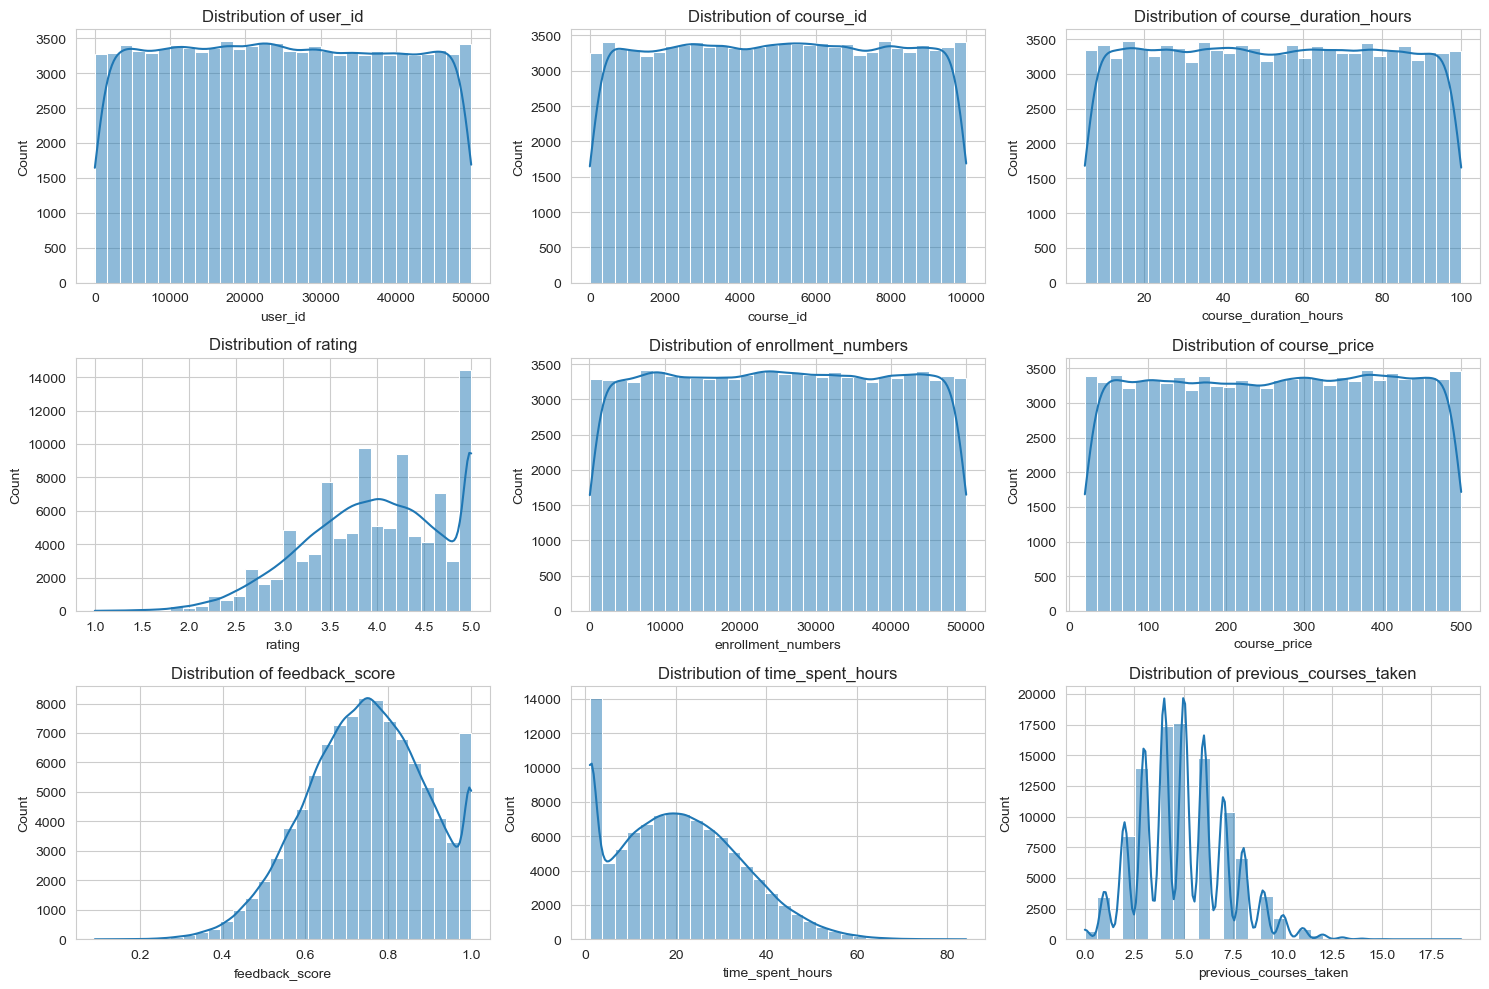

In [7]:
sns.set_style("whitegrid")
# 3) DISTRIBUTIONS (NUMERIC)
# =======================
plt.figure(figsize=(15, 10))
for i, col in enumerate(numeric_cols, 1):
    plt.subplot(3, 3, i)
    sns.histplot(df[col], bins=30, kde=True)
    plt.title(f"Distribution of {col}")
plt.tight_layout()
plt.show()

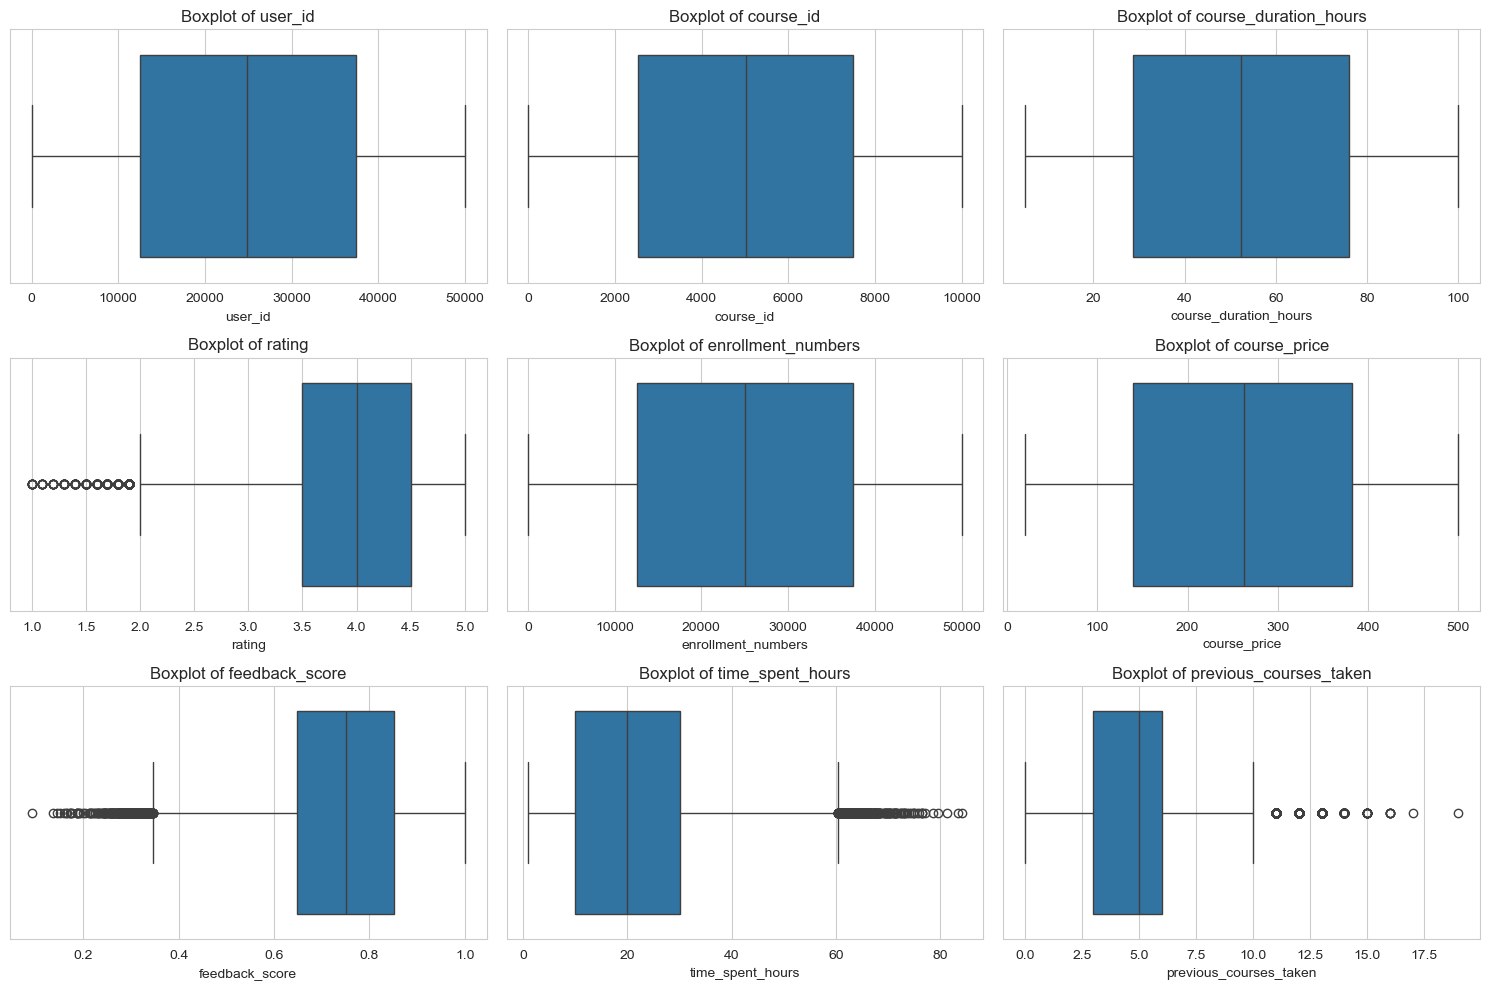

In [8]:
# 4) BOXPLOTS (Outliers)
# =======================
plt.figure(figsize=(15, 10))
for i, col in enumerate(numeric_cols, 1):
    plt.subplot(3, 3, i)
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
plt.tight_layout()
plt.show()

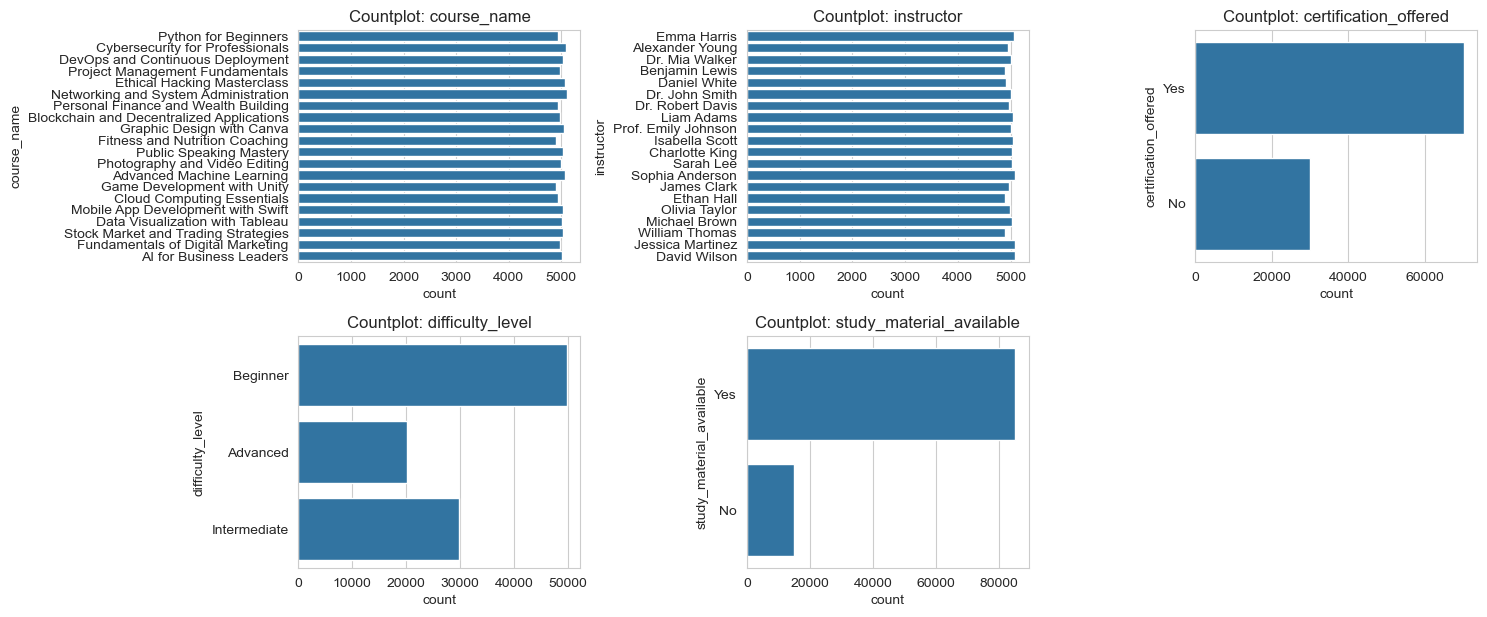

In [9]:
# 5) COUNT PLOTS (CATEGORICAL)
# =======================
plt.figure(figsize=(15, 12))
for i, col in enumerate(categorical_cols, 1):
    plt.subplot(4, 3, i)

    temp = df[col].fillna("Unknown")

    if temp.nunique() > 20:
        top10 = temp.value_counts().nlargest(10).index
        sns.countplot(y=temp[temp.isin(top10)], order=top10)
    else:
        sns.countplot(y=temp)

    plt.title(f"Countplot: {col}")

plt.tight_layout()
plt.show()

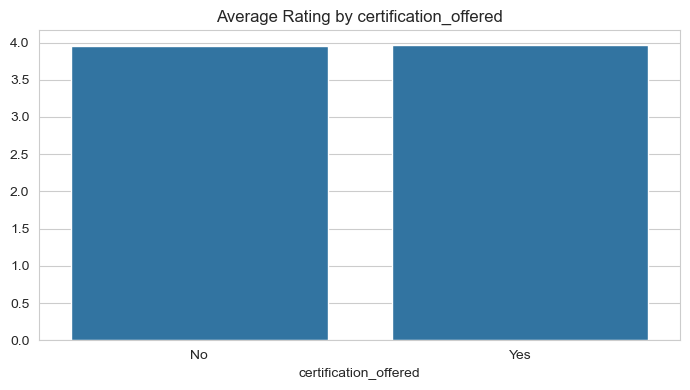

In [10]:
# 6) AVG RATING BY DIFFICULTY
# =======================
if "certification_offered" in df and "rating" in df:
    plt.figure(figsize=(7, 4))
    avg_rating = df.groupby("certification_offered")["rating"].mean().sort_values()
    sns.barplot(x=avg_rating.index, y=avg_rating.values)
    plt.title("Average Rating by certification_offered")
    plt.tight_layout()
    plt.show()


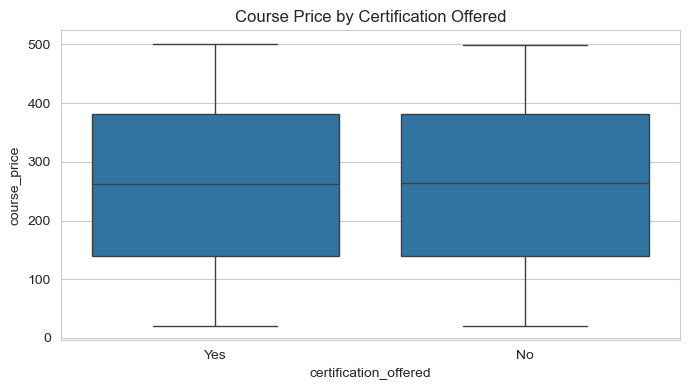

In [11]:
# 7) COURSE PRICE VS CERTIFICATION
# =======================
if "certification_offered" in df and "course_price" in df:
    plt.figure(figsize=(7, 4))
    sns.boxplot(x="certification_offered", y="course_price", data=df)
    plt.title("Course Price by Certification Offered")
    plt.tight_layout()
    plt.show()


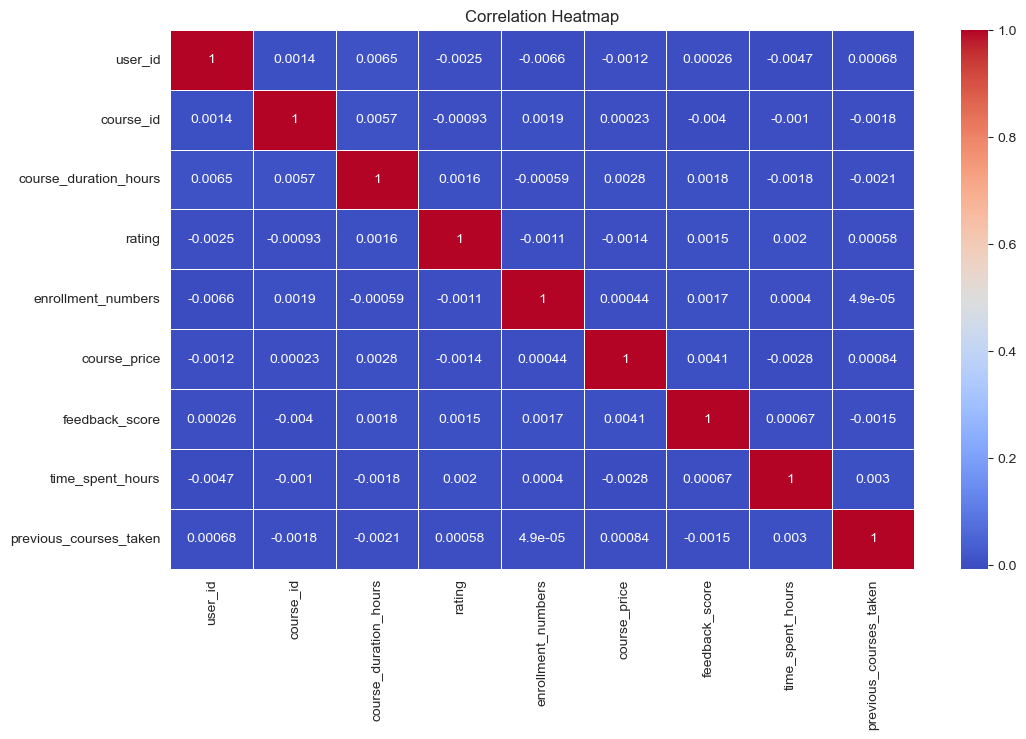

In [12]:
# 8) CORRELATION HEATMAP
# =======================
plt.figure(figsize=(12, 7))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()

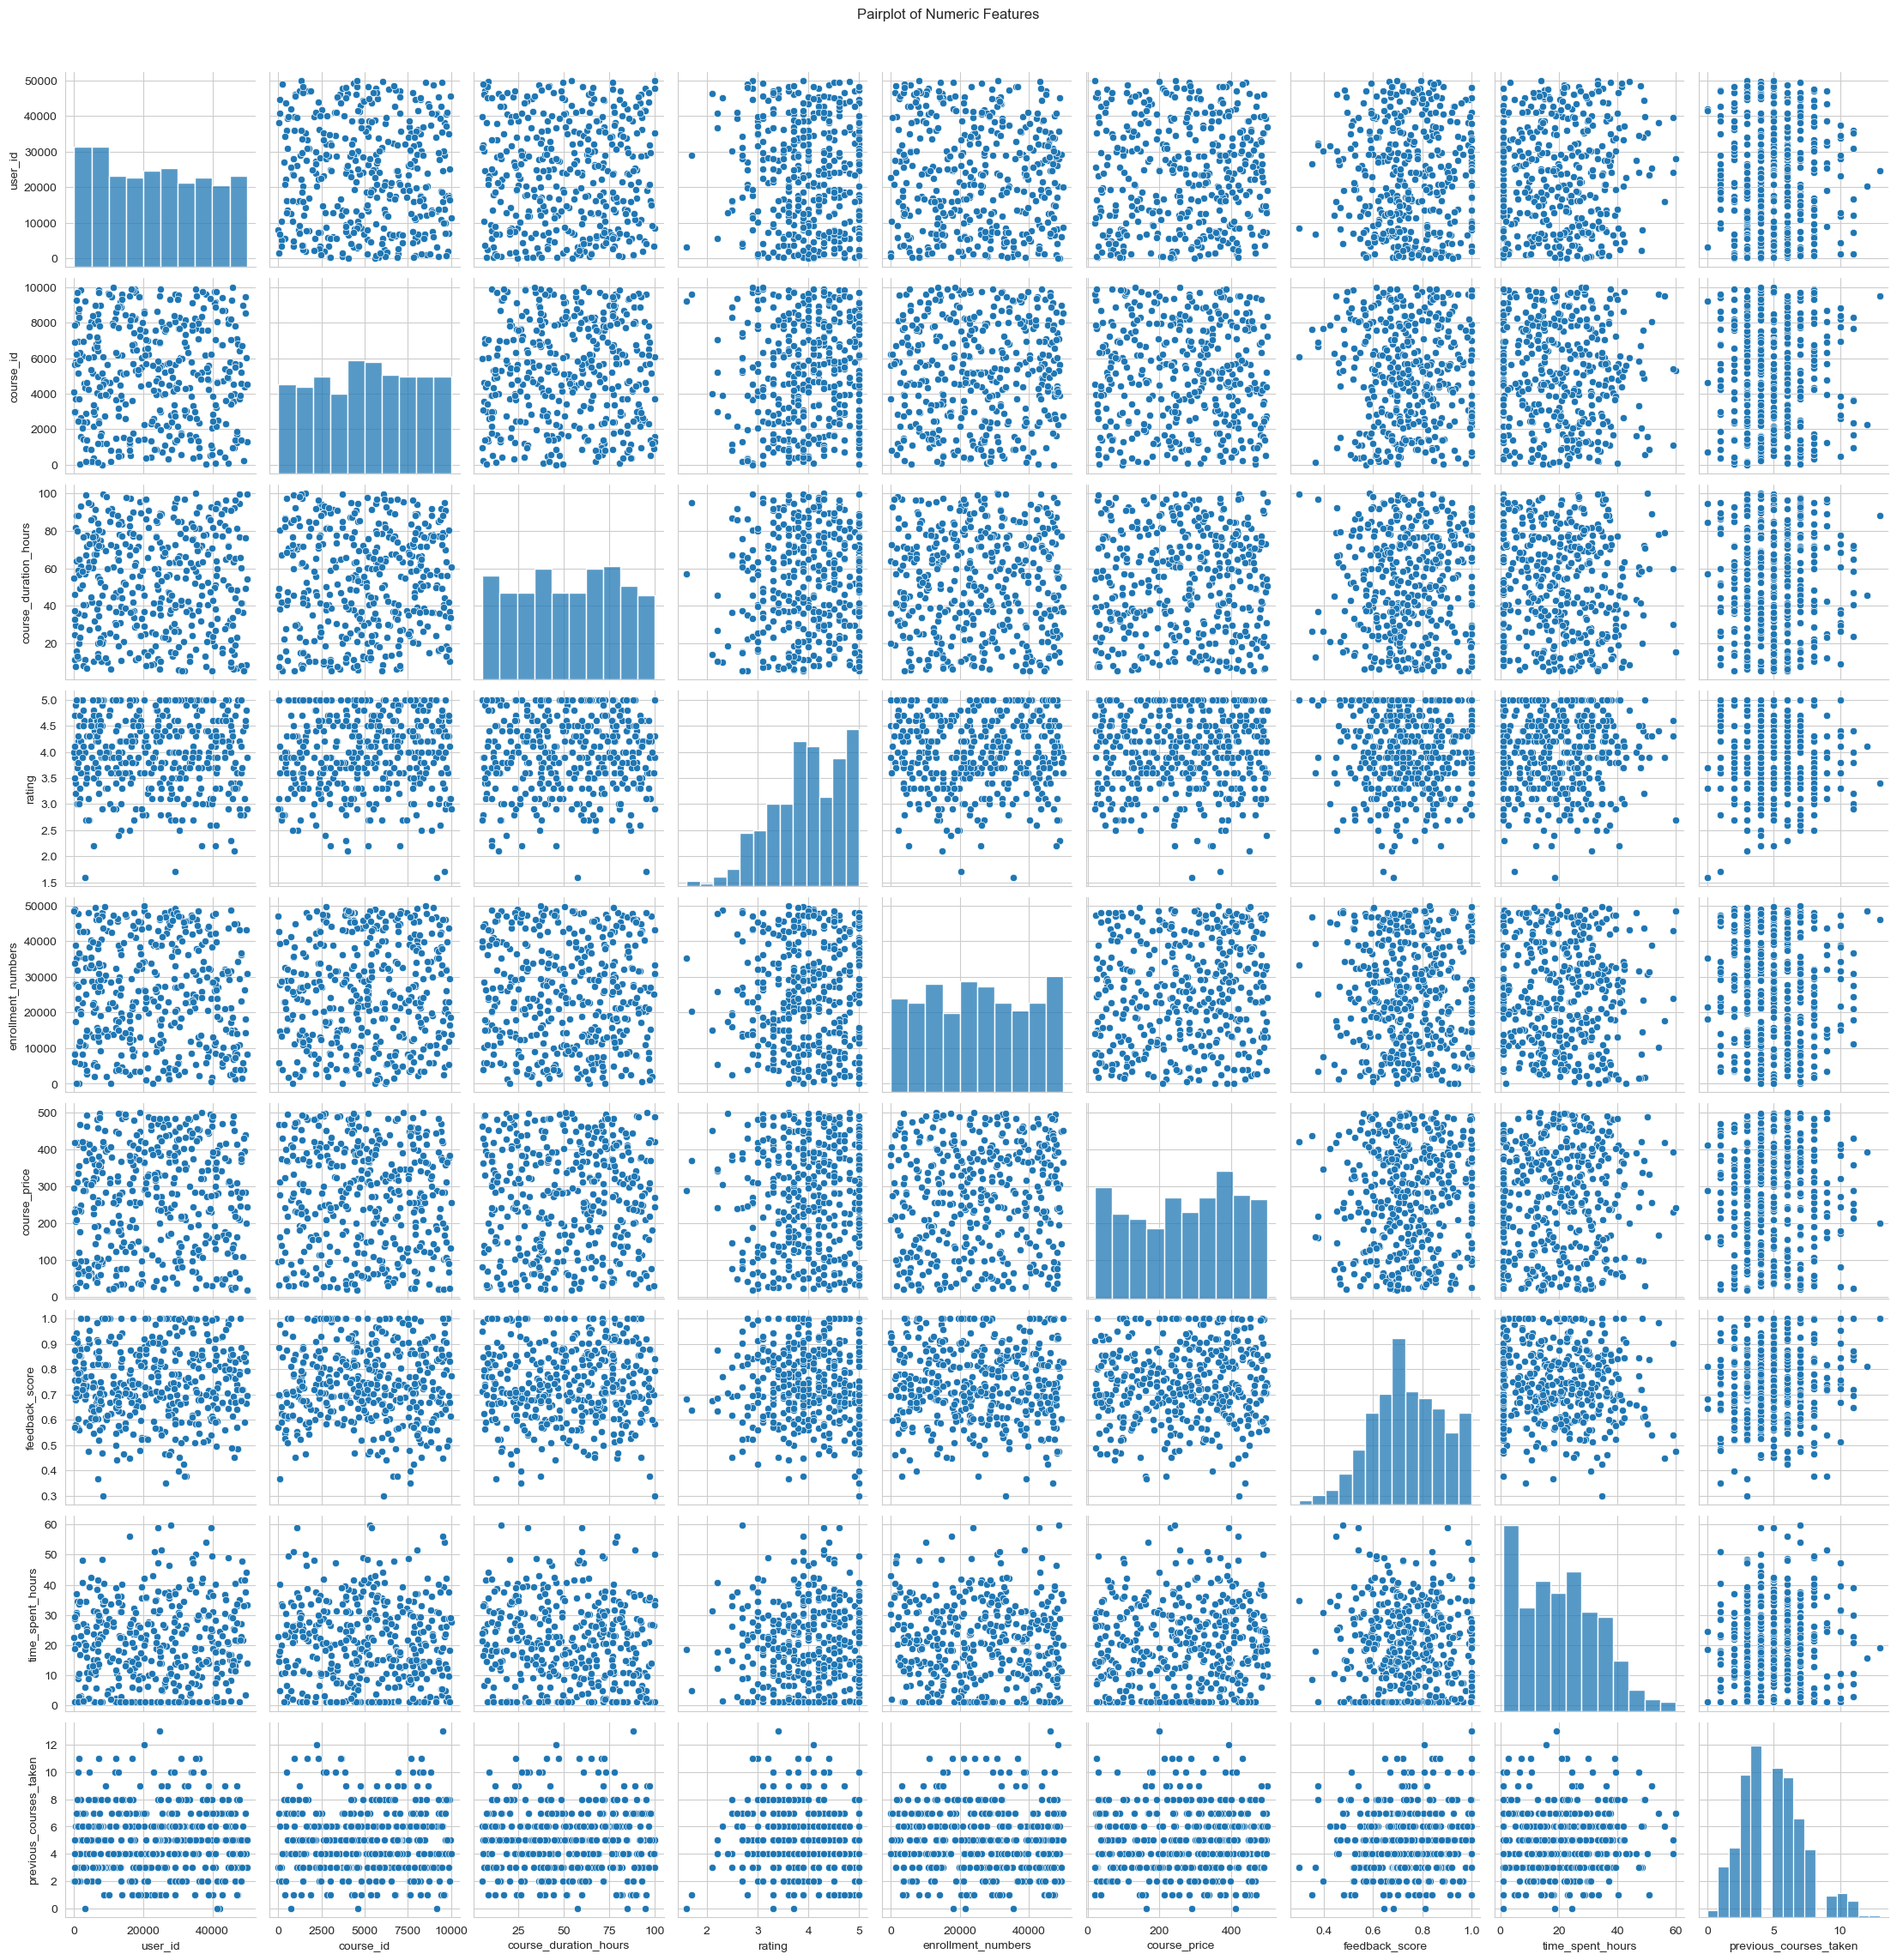

In [13]:
# 9) PAIRPLOT (Sample to avoid heavy load)
# =======================
if len(numeric_cols) > 1:
    sample_df = df[numeric_cols].sample(min(400, len(df)), random_state=42)
    sns.pairplot(sample_df)
    plt.suptitle("Pairplot of Numeric Features", y=1.02)
    plt.show()

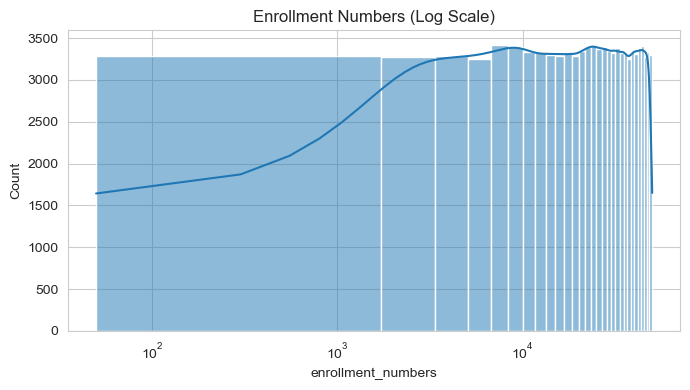

In [14]:
# 10) ENROLLMENT LOG SCALE
# =======================
if "enrollment_numbers" in df:
    plt.figure(figsize=(7, 4))
    valid = df[df["enrollment_numbers"] > 0]
    sns.histplot(valid["enrollment_numbers"], bins=30, kde=True)
    plt.xscale("log")
    plt.title("Enrollment Numbers (Log Scale)")
    plt.tight_layout()
    plt.show()

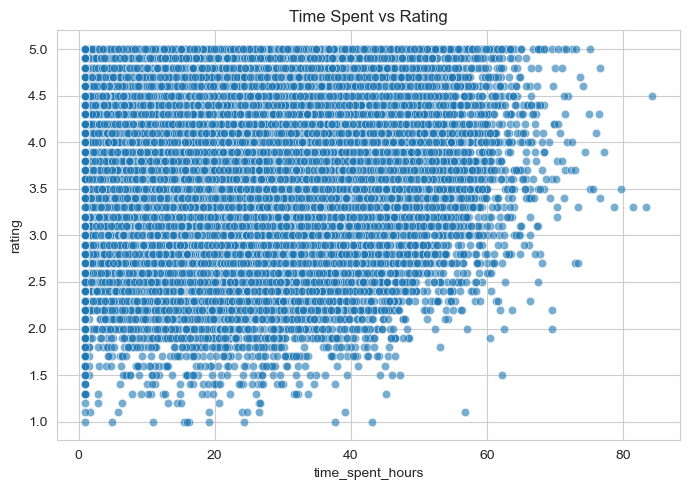

In [15]:
# 11) TIME SPENT vs RATING
# =======================
if "time_spent_hours" in df and "rating" in df:
    plt.figure(figsize=(7, 5))
    sns.scatterplot(x="time_spent_hours", y="rating", data=df, alpha=0.6)
    plt.title("Time Spent vs Rating")
    plt.tight_layout()
    plt.show()

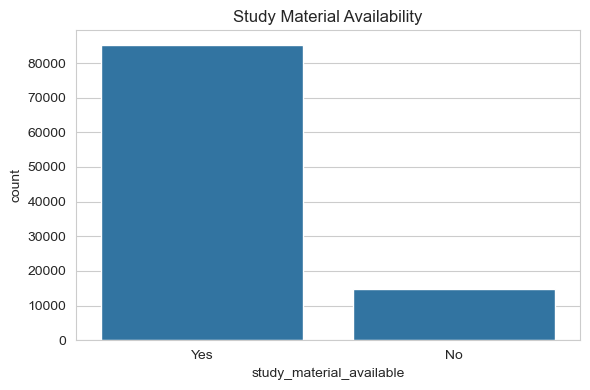

In [16]:
# 12) STUDY MATERIAL AVAILABLE
# =======================
if "study_material_available" in df:
    plt.figure(figsize=(6, 4))
    sns.countplot(x="study_material_available", data=df)
    plt.title("Study Material Availability")
    plt.tight_layout()
    plt.show()

In [17]:
# 13) SKEWNESS & KURTOSIS
# =======================
print("\n=== SKEWNESS ===")
print(df[numeric_cols].skew())

print("\n=== KURTOSIS ===")
print(df[numeric_cols].kurt())


=== SKEWNESS ===
user_id                   0.012595
course_id                -0.001061
course_duration_hours     0.003957
rating                   -0.424633
enrollment_numbers       -0.001392
course_price             -0.012440
feedback_score           -0.232178
time_spent_hours          0.412810
previous_courses_taken    0.442478
dtype: float64

=== KURTOSIS ===
user_id                  -1.192318
course_id                -1.194171
course_duration_hours    -1.200790
rating                   -0.349763
enrollment_numbers       -1.195687
course_price             -1.206528
feedback_score           -0.322079
time_spent_hours         -0.352988
previous_courses_taken    0.214430
dtype: float64


In [18]:
# ====== 4) FEATURE ENGINEERING (clean,) ======
# Create derived features (engagement_score, price/rating bins) and convert yes/no/difficulty to numeric.
# Use one mapping step per column and use new column names for encoded values — do NOT overwrite original until finished.
df_fe = df.copy()  # work on a feature-engineered copy and keep original df intact if needed

# Map Yes/No columns to 0/1 only if they exist and are not already numeric
yes_no_cols = ['certification_offered', 'study_material_available']
for col in yes_no_cols:
    if col in df_fe.columns:
        # Avoid remapping if already numeric (0/1)
        if df_fe[col].dtype == object or not set(df_fe[col].unique()).issubset({0,1}):
            df_fe[col + '_bin'] = df_fe[col].map({'Yes': 1, 'No': 0})
        else:
            df_fe[col + '_bin'] = df_fe[col].astype(int)

# Map difficulty to ordinal scale (Beginner=1, Intermediate=2, Advanced=3)
if 'difficulty_level' in df_fe.columns:
    difficulty_mapping = {'Beginner': 1, 'Intermediate': 2, 'Advanced': 3}
    # If already numeric, keep as-is; otherwise map and store to new column
    if df_fe['difficulty_level'].dtype == object:
        df_fe['difficulty_level_ord'] = df_fe['difficulty_level'].map(difficulty_mapping)
    else:
        df_fe['difficulty_level_ord'] = df_fe['difficulty_level']

# Create engagement score with safe checks for feature existence
def safe_col(col):
    return col if col in df_fe.columns else None

time_col = safe_col('time_spent_hours')
prev_courses_col = safe_col('previous_courses_taken')
feedback_col = safe_col('feedback_score')

# Weighted engagement: uses available columns only.
engagement_components = []
if time_col:
    engagement_components.append(('time_spent_hours', 0.4))
if prev_courses_col:
    engagement_components.append(('previous_courses_taken', 0.3))
if feedback_col:
    engagement_components.append(('feedback_score', 0.3))

if len(engagement_components) > 0:
    df_fe['engagement_score'] = 0
    for comp, weight in engagement_components:
        df_fe['engagement_score'] += df_fe[comp] * weight
else:
    df_fe['engagement_score'] = 0  # fallback if none exist

# Price and rating categories (bins) — create as categorical strings then optionally label-encode
if 'course_price' in df_fe.columns:
    df_fe['price_category'] = pd.cut(
        df_fe['course_price'],
        bins=[-1, 100, 200, 400, df_fe['course_price'].max()],
        labels=['Low', 'Medium', 'High', 'VeryHigh']
    ).astype(str)

if 'rating' in df_fe.columns:
    df_fe['rating_category'] = pd.cut(
        df_fe['rating'],
        bins=[-1, 2.5, 3.5, 5],
        labels=['Poor', 'Average', 'Good']
    ).astype(str)

# Label-encode high-cardinality text columns using separate encoders and store as new columns.
from sklearn.preprocessing import LabelEncoder
le_instructor = None
le_course = None

if 'instructor' in df_fe.columns:
    le_instructor = LabelEncoder()
    df_fe['instructor_encoded'] = le_instructor.fit_transform(df_fe['instructor'].astype(str))

if 'course_name' in df_fe.columns:
    le_course = LabelEncoder()
    df_fe['course_name_encoded'] = le_course.fit_transform(df_fe['course_name'].astype(str))

# Drop raw columns only after we've created safe encoded versions (to avoid losing original info).
cols_to_drop = []
if 'instructor' in df_fe.columns and 'instructor_encoded' in df_fe.columns:
    cols_to_drop.append('instructor')
if 'course_name' in df_fe.columns and 'course_name_encoded' in df_fe.columns:
    cols_to_drop.append('course_name')

df_fe = df_fe.drop(columns=cols_to_drop)

print("\nFeature-engineered columns added. Sample:")
display(df_fe.head())


Feature-engineered columns added. Sample:


,user_id,course_id,course_duration_hours,certification_offered,difficulty_level,rating,enrollment_numbers,course_price,feedback_score,study_material_available,time_spent_hours,previous_courses_taken,certification_offered_bin,study_material_available_bin,difficulty_level_ord,engagement_score,price_category,rating_category,instructor_encoded,course_name_encoded
0,15796,9366,39.1,Yes,Beginner,5.0,21600,317.50,0.797,Yes,17.60,4,1,1,1,8.4791,High,Good,8,18
1,861,1928,36.3,Yes,Beginner,4.3,15379,40.99,0.770,Yes,28.97,9,1,1,1,14.5190,Low,Good,0,4
2,38159,9541,13.4,Yes,Beginner,3.9,6431,380.81,0.772,Yes,52.44,4,1,1,1,22.4076,High,Good,6,6
3,44733,3708,58.3,Yes,Beginner,3.1,48245,342.80,0.969,No,22.29,6,1,0,1,11.0067,High,Average,1,16
4,11285,3361,30.8,Yes,Beginner,2.8,34556,381.01,0.555,Yes,22.01,5,1,1,1,10.4705,High,Average,3,7


In [19]:
# ====== 5) OUTLIER HANDLING (IQR capping on numeric features) ======
# Detect and cap extreme outliers using IQR on numeric features; this is safer than deleting rows.
# We apply capping to a copy (df_fe) and keep columns consistent for modeling.
numeric_cols_fe = df_fe.select_dtypes(include=[np.number]).columns.tolist()

# Exclude ID-like columns if detected (e.g., user_id or course_id should not be treated as continuous)
for id_col in ['user_id', 'course_id', 'id']:
    if id_col in numeric_cols_fe:
        numeric_cols_fe.remove(id_col)

# Cap via IQR (clip to [Q1 - 1.5*IQR, Q3 + 1.5*IQR])
for col in numeric_cols_fe:
    Q1 = df_fe[col].quantile(0.25)
    Q3 = df_fe[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    df_fe[col] = df_fe[col].clip(lower=lower, upper=upper)

print("Outlier capping applied to numeric features.")

Outlier capping applied to numeric features.


In [1]:
# ====== 6) FINAL PREP: SELECT FEATURES & TARGET ======
# Choose model features carefully: use engineered numeric columns and encoded categorical columns.
# Make sure all features we include are numeric; otherwise convert or drop them.
potential_features = [
    'course_duration_hours', 'certification_offered_bin', 'difficulty_level_ord',
    'enrollment_numbers', 'course_price', 'feedback_score', 'study_material_available_bin',
    'time_spent_hours', 'previous_courses_taken', 'instructor_encoded', 'course_name_encoded',
    'engagement_score'
]

# Filter features to those actually present in df_fe
features = [f for f in potential_features if f in df_fe.columns]
target = 'rating'
if target not in df_fe.columns:
    raise ValueError(f"Target column '{target}' not found in dataset. Please confirm the Excel file.")

X = df_fe[features].copy()
y = df_fe[target].copy()

print("\nFinal features to be used in modeling:", 
      features)
print("Target:", target)
print("X shape:", X.shape, "y shape:", y.shape)

NameError: name 'df_fe' is not defined

In [21]:
# ====== 7) TRAIN-TEST SPLIT (no leakage) ======
# Split the dataset before scaling / standardization to avoid data leakage in preprocessing.
# Use stratify if rating_category exists for balanced split, otherwise regular split.
from sklearn.model_selection import train_test_split
stratify_col = df_fe['rating_category'] if 'rating_category' in df_fe.columns else None

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=stratify_col if stratify_col is not None else None
)

print("\nTrain/Test shapes:", X_train.shape, X_test.shape)


Train/Test shapes: (80000, 12) (20000, 12)


In [24]:
# ====== ) CONTENT-BASED FILTERING (FINAL WORKING VERSION) ======
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.neighbors import NearestNeighbors

# Create combined text for similarity
df_fe['combined_text'] = (
    df_fe['course_name_encoded'].astype(str) + " " +
    df_fe['difficulty_level'].astype(str) + " " +
    df_fe['rating_category'].astype(str)
)

# TF-IDF Vectorizer
tfidf = TfidfVectorizer(stop_words='english')
tfidf_matrix = tfidf.fit_transform(df_fe['combined_text'])

# KNN Model
knn_model = NearestNeighbors(metric='cosine', algorithm='brute')
knn_model.fit(tfidf_matrix)

# Course index mapping
indices = pd.Series(df_fe.index, index=df_fe['course_name_encoded']).drop_duplicates()


# FINAL FIXED CONTENT-BASED FUNCTION
def content_based_recommend(course_code, top_n=5):

    if course_code not in indices.index:
        return pd.DataFrame({"Error": [f"Course code {course_code} not found"]})

    idx = indices[course_code]  # get row index

    distances, neighbor_indices = knn_model.kneighbors(
        tfidf_matrix[idx],
        n_neighbors=top_n + 1
    )

    # remove the course itself
    neighbor_indices = neighbor_indices.flatten()[1:]

    # return recommended courses
    return df_fe.loc[neighbor_indices, [
    "course_id",
    "course_name_encoded",
    "rating",
    "difficulty_level",
    "rating_category"
]].reset_index(drop=True)

display(content_based_recommend(df_fe['course_name_encoded'].iloc[0]))


,course_id,course_name_encoded,rating,difficulty_level,rating_category
0,4194,18,4.4,Beginner,Good
1,4942,18,4.0,Beginner,Good
2,2384,18,4.5,Beginner,Good
3,7279,18,4.5,Beginner,Good
4,1954,18,3.7,Beginner,Good
...,...,...,...,...,...
29580,3843,18,2.7,Beginner,Average
29581,571,18,3.1,Beginner,Average
29582,5440,18,3.2,Beginner,Average
29583,1151,18,3.5,Beginner,Average


In [25]:
# ====== 13) COLLABORATIVE FILTERING (Memory Safe Version) ======
from sklearn.neighbors import NearestNeighbors

# Required columns check
required_cols = ['user_id', 'course_name_encoded', 'rating']
for col in required_cols:
    if col not in df_fe.columns:
        raise ValueError(f"Missing required column: {col}")

# Create user-item matrix
user_item_matrix = df_fe.pivot_table(
    index='user_id',
    columns='course_name_encoded',
    values='rating'
).fillna(0)

# Fit KNN model on users
knn_user_model = NearestNeighbors(metric='cosine', algorithm='brute')
knn_user_model.fit(user_item_matrix.values)

# Mapping user index to actual user_id
user_index_map = list(user_item_matrix.index)

def collaborative_recommend(user_id, top_n=5):
    if user_id not in user_item_matrix.index:
        raise ValueError("User ID not found in dataset.")
    
    # Find nearest users (similar users)
    user_idx = user_index_map.index(user_id)
    distances, indices = knn_user_model.kneighbors(
        user_item_matrix.iloc[user_idx].values.reshape(1, -1),
        n_neighbors=6   # 1 = user itself + 5 similar users
    )
    
    similar_users = [user_index_map[i] for i in indices.flatten()[1:]]
    
    # Ratings from similar users
    similar_ratings = user_item_matrix.loc[similar_users]
    
    # Weighted score calculation
    distance_scores = (1 - distances.flatten()[1:])
    weighted_scores = similar_ratings.T.dot(distance_scores)
    
    recommendation_scores = weighted_scores / distance_scores.sum()
    
    # Remove courses already taken by the user
    user_taken = user_item_matrix.loc[user_id]
    recommendation_scores = recommendation_scores[user_taken == 0]

    # Top recommendations
    top_recommend = recommendation_scores.sort_values(ascending=False).head(top_n)

    return df_fe[df_fe['course_name_encoded'].isin(top_recommend.index)] \
              [['course_name_encoded', 'rating', 'difficulty_level', 'rating_category']] \
              .drop_duplicates() \
              .head(top_n)


print("\nCollaborative Filtering Example:")
display(collaborative_recommend(df_fe['user_id'].iloc[0]))



Collaborative Filtering Example:


,course_name_encoded,rating,difficulty_level,rating_category
3,16,3.1,Beginner,Average
12,17,4.1,Intermediate,Good
14,15,4.1,Advanced,Good
17,1,4.0,Intermediate,Good
20,15,2.5,Advanced,Poor


In [26]:
# ====== 14) HYBRID RECOMMENDER (TF-IDF Content + User KNN Collaborative) ======

def hybrid_recommend(user_id, top_n=5, alpha=0.6):
    """
    Hybrid Recommendation:
    alpha = weight for Content-based (0 to 1)
    (1-alpha) = weight for Collaborative Filtering
    """

    # ---- 1) Collaborative Recommendations ----
    try:
        collab_recs = collaborative_recommend(user_id, top_n=20)
        collab_ids = collab_recs['course_name_encoded'].values
    except:
        collab_ids = []

    # Convert to score dict
    collab_scores = {cid: (20 - i) for i, cid in enumerate(collab_ids)}

    # ---- 2) Content-Based Recommendations ----
    # Get user's most recent course
    last_course = df_fe[df_fe['user_id'] == user_id]['course_name_encoded'].iloc[-1]

    # Use content-based recommend function from Step 12
    content_recs = content_based_recommend(last_course, top_n=20)
    content_ids = content_recs['course_name_encoded'].values

    # Convert to score dict
    content_scores = {cid: (20 - i) for i, cid in enumerate(content_ids)}

    # ---- 3) Combine Scores ----
    hybrid_scores = {}

    # Add content scores
    for cid, score in content_scores.items():
        hybrid_scores[cid] = alpha * score

    # Add collaborative scores
    for cid, score in collab_scores.items():
        if cid in hybrid_scores:
            hybrid_scores[cid] += (1 - alpha) * score
        else:
            hybrid_scores[cid] = (1 - alpha) * score

    # Sort final combined scores
    final_sorted = sorted(hybrid_scores.items(), key=lambda x: x[1], reverse=True)

    # Select top-N courses
    top_final = [cid for cid, sc in final_sorted[:top_n]]

    # ---- 4) Return Final Courses ----
    return df_fe[df_fe['course_name_encoded'].isin(top_final)] \
         [['course_id', 'course_name_encoded', "rating", "difficulty_level", "rating_category"]] \
         .drop_duplicates() \
         .head(top_n)

print("\nHybrid Recommender Example:")
display(hybrid_recommend(df_fe['user_id'].iloc[0]))



Hybrid Recommender Example:


,course_id,course_name_encoded,rating,difficulty_level,rating_category
3,3708,16,3.1,Beginner,Average
6,7887,13,4.9,Beginner,Good
8,1578,14,4.7,Beginner,Good
10,6716,11,4.5,Beginner,Good
12,2425,17,4.1,Intermediate,Good


In [27]:
# ====== 15) EXPLAINABILITY FOR HYBRID RECOMMENDER ======

def explain_recommendation(user_id, course_code, alpha=0.6):
    explanation = {}

    # 1) Collaborative similarity (Top users)
    try:
        user_idx = user_index_map.index(user_id)
        distances, indices = knn_user_model.kneighbors(
            user_item_matrix.iloc[user_idx].values.reshape(1, -1),
            n_neighbors=6
        )

        similar_users = [user_index_map[i] for i in indices.flatten()[1:]]
        similar_distances = (1 - distances.flatten()[1:])

        explanation["similar_users"] = list(zip(similar_users, similar_distances))
    except:
        explanation["similar_users"] = []

    # 2) Content similarity for the target course
    last_course = df_fe[df_fe['user_id'] == user_id]['course_name_encoded'].iloc[-1]

    # Content similarity using Step 12
    recs = content_based_recommend(last_course, top_n=50)
    rec_dict = {cid: (50 - i) for i, cid in enumerate(recs['course_name_encoded'])}

    explanation["content_similarity_score"] = rec_dict.get(course_code, 0)

    # 3) Hybrid weight used
    explanation["hybrid_alpha_weight"] = alpha

    return explanation


# Example:
user_id_sample = df_fe['user_id'].iloc[0]
sample_course = hybrid_recommend(user_id_sample).iloc[0]['course_name_encoded']

print("Explanation Example:")
explain_recommendation(user_id_sample, sample_course)


Explanation Example:


{'similar_users': [(436, 0.9999706042420466),
  (11487, 0.9999115950201516),
  (25576, 0.9999115950201516),
  (12821, 0.9999115950201516),
  (48035, 0.999810308668241)],
 'content_similarity_score': 0,
 'hybrid_alpha_weight': 0.6}

In [28]:
import joblib
import os

# Create folder if it doesn't exist
os.makedirs("saved_models", exist_ok=True)

# Save the models and objects from previous steps

# 1) Save TF-IDF Vectorizer (Content-Based Filtering)
joblib.dump(tfidf, "saved_models/tfidf_vectorizer.pkl")

# 2) Save KNN model for Content-Based Filtering
joblib.dump(knn_model, "saved_models/content_knn_model.pkl")

# 3) Save KNN model for Collaborative Filtering (User-based)
joblib.dump(knn_user_model, "saved_models/user_knn_model.pkl")

# 4) Save Encoded DataFrame (used for mapping, features, etc.)
joblib.dump(df_fe, "saved_models/df_fe.pkl")

# 5) Save User-Item Matrix (for collaborative filtering)
joblib.dump(user_item_matrix, "saved_models/user_item_matrix.pkl")

# 6) Save course index mapping (used in content filtering)
joblib.dump(indices, "saved_models/course_index_map.pkl")

# 7) Save user index mapping (used in collaborative filtering)
joblib.dump(user_index_map, "saved_models/user_index_map.pkl")

print("✅ All models and required objects saved successfully inside 'saved_models' folder!")


✅ All models and required objects saved successfully inside 'saved_models' folder!
